In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.6 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!unzip /content/recyclability_model_v2.keras.zip

Archive:  /content/recyclability_model_v2.keras.zip
replace metadata.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: metadata.json           
replace config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: config.json             
replace model.weights.h5? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: model.weights.h5        


In [ ]:
import os
import shutil

os.makedirs("/content/model1", exist_ok=True)

shutil.move("/content/config.json", "/content/model1/config.json")
shutil.move("/content/metadata.json", "/content/model1/metadata.json")
shutil.move("/content/model.weights.h5", "/content/model1/model.weights.h5")

'/content/model1/model.weights.h5'

In [ ]:
model1 = tf.keras.models.load_model("/content/model1")

model2 = tf.keras.models.load_model("/content/waste_classifier_effnetB4_final.h5")

model3 = YOLO("/content/best (1).pt")

In [ ]:
binary_classes = ["Recyclable", "Unrecyclable"]

class_names_model2 = [
    'E-waste',
    'automobile wastes',
    'battery waste',
    'glass waste',
    'light bulbs',
    'metal waste',
    'organic waste',
    'paper waste',
    'plastic waste'
]

In [ ]:
def preprocess_model1(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [ ]:
def preprocess_model2(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(380, 380))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [ ]:
def preprocess_model3(img_path):
    return img_path

In [ ]:
def run_pipeline(img_path):
    print("📸 Input Image:", img_path)


    img = cv2.imread(img_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis("off")
    plt.show()


    img1 = preprocess_model1(img_path)
    pred1 = model1.predict(img1)

    print("Raw prediction:", pred1)

    confidence1 = float(pred1[0][0])


    if confidence1 > 0.5:
        result1 = "Unrecyclable"
    else:
        result1 = "Recyclable"

    print(f"\n🔹 Model 1 Prediction: {result1} ({confidence1:.4f})")

    if result1 == "Unrecyclable":
        print("⛔ Stopping pipeline (not recyclable)")

        return {
            "recyclable": result1,
            "confidence_model1": confidence1,
            "category": None,
            "detections": None
        }

    # ========================
    # STEP 2 → Model 2
    # ========================
    img2 = preprocess_model2(img_path)
    pred2 = model2.predict(img2)

    label2 = np.argmax(pred2)
    confidence2 = float(np.max(pred2))
    result2 = class_names_model2[label2]

    print(f"🔹 Model 2 Prediction: {result2} ({confidence2:.4f})")


    print("\n🔹 Running YOLO Detection...")

    results = model3.predict(
        source=img_path,
        conf=0.25,
        save=True
    )

    detected_objects = []

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            cls_name = model3.names[cls_id]
            detected_objects.append(cls_name)


    detected_objects = list(set(detected_objects))

    print("🔹 Detected Objects:", detected_objects)
    print("✅ Detection complete (check output images)")


    return {
        "recyclable": result1,
        "confidence_model1": confidence1,
        "category": result2,
        "confidence_model2": confidence2,
        "detections": detected_objects
    }

📸 Input Image: /content/organicwaste.jpeg


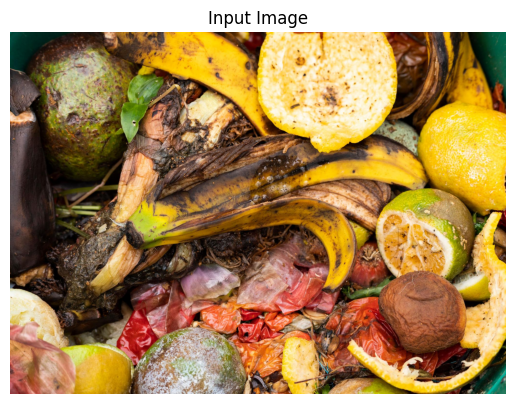

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Raw prediction: [[          1]]

🔹 Model 1 Prediction: Unrecyclable (1.0000)
⛔ Stopping pipeline (not recyclable)


{'recyclable': 'Unrecyclable',
 'confidence_model1': 0.9999995231628418,
 'category': None,
 'detections': None}

In [ ]:
run_pipeline("/content/organicwaste.jpeg")

📸 Input Image: /content/organic_waste.jpeg


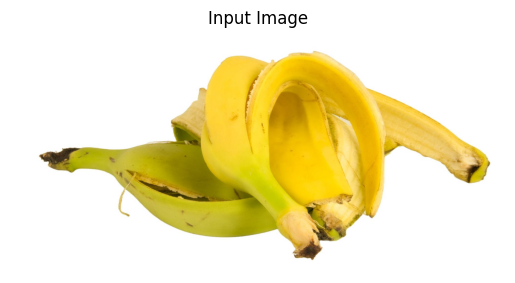

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Raw prediction: [[    0.99668]]

🔹 Model 1 Prediction: Unrecyclable (0.9967)
⛔ Stopping pipeline (not recyclable)


{'recyclable': 'Unrecyclable',
 'confidence_model1': 0.9966810345649719,
 'category': None,
 'detections': None}

In [ ]:
run_pipeline("/content/organic_waste.jpeg")

📸 Input Image: /content/glasswaste.jpeg


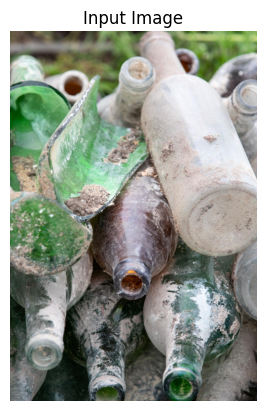

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Raw prediction: [[  0.0026438]]

🔹 Model 1 Prediction: Recyclable (0.0026)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
🔹 Model 2 Prediction: glass waste (0.4730)

🔹 Running YOLO Detection...

image 1/1 /content/glasswaste.jpeg: 640x448 1 Bottle, 44.4ms
Speed: 2.8ms preprocess, 44.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Bottle']
✅ Detection complete (check output images)


{'recyclable': 'Recyclable',
 'confidence_model1': 0.0026437717024236917,
 'category': 'glass waste',
 'confidence_model2': 0.47299352288246155,
 'detections': ['Bottle']}

In [ ]:
run_pipeline("/content/glasswaste.jpeg")

📸 Input Image: /content/broken_glass.jpeg


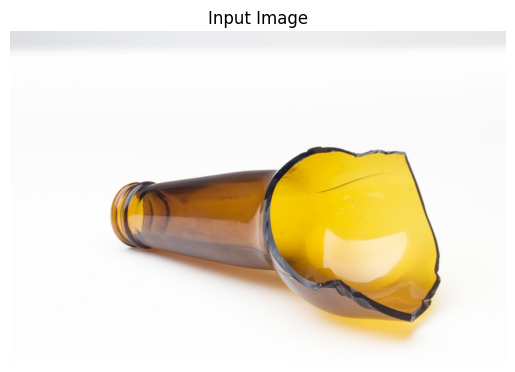

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Raw prediction: [[ 7.4762e-07]]

🔹 Model 1 Prediction: Recyclable (0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
🔹 Model 2 Prediction: glass waste (0.9977)

🔹 Running YOLO Detection...

image 1/1 /content/broken_glass.jpeg: 448x640 1 Bottle cap, 13.5ms
Speed: 2.8ms preprocess, 13.5ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Bottle cap']
✅ Detection complete (check output images)


{'recyclable': 'Recyclable',
 'confidence_model1': 7.476216410395864e-07,
 'category': 'glass waste',
 'confidence_model2': 0.9976782202720642,
 'detections': ['Bottle cap']}

In [ ]:
run_pipeline("/content/broken_glass.jpeg")

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import cv2
import numpy as np

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    binary = base64.b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


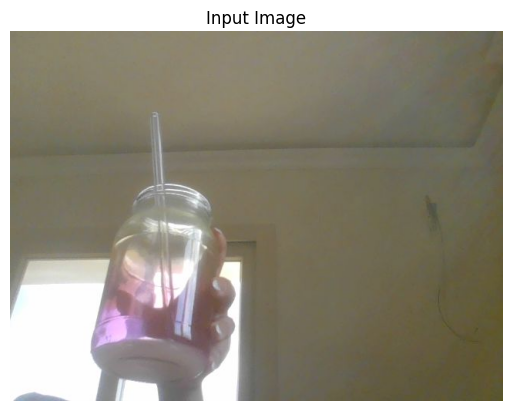

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Raw prediction: [[ 5.3775e-05]]

🔹 Model 1 Prediction: Recyclable (0.0001)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
🔹 Model 2 Prediction: glass waste (0.4523)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 1 Cup, 13.3ms
Speed: 2.2ms preprocess, 13.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Cup']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 5.377518755267374e-05, 'category': 'glass waste', 'confidence_model2': 0.4523221254348755, 'detections': ['Cup']}


In [ ]:
img_path = take_photo()

result3 = run_pipeline(img_path)
print(result3)

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


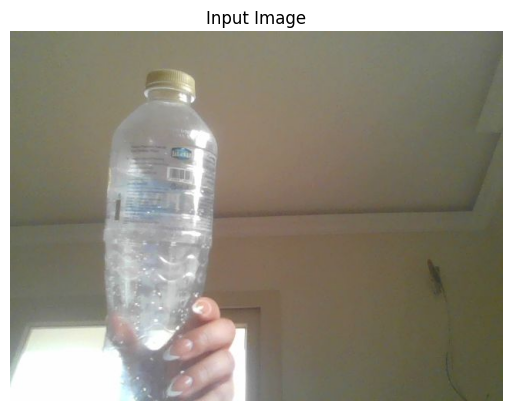

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Raw prediction: [[ 4.0323e-07]]

🔹 Model 1 Prediction: Recyclable (0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
🔹 Model 2 Prediction: plastic waste (0.9268)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 1 Bottle cap, 1 Bottle, 13.0ms
Speed: 2.4ms preprocess, 13.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Bottle cap', 'Bottle']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 4.032267781894916e-07, 'category': 'plastic waste', 'confidence_model2': 0.926801860332489, 'detections': ['Bottle cap', 'Bottle']}


In [ ]:
img_path = take_photo()

result4 = run_pipeline(img_path)
print(result4)

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


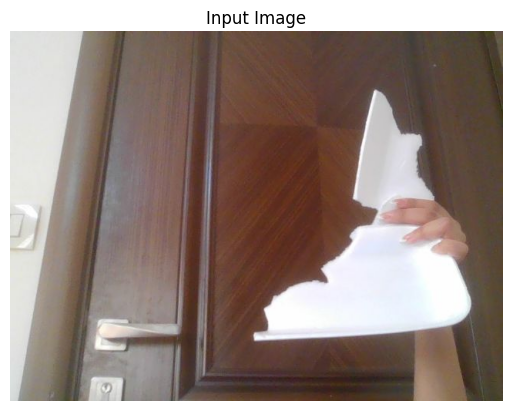

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Raw prediction: [[    0.28255]]

🔹 Model 1 Prediction: Recyclable (0.2826)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
🔹 Model 2 Prediction: paper waste (0.9332)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 2 Styrofoam pieces, 12.9ms
Speed: 2.0ms preprocess, 12.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Styrofoam piece']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 0.2825535237789154, 'category': 'paper waste', 'confidence_model2': 0.9332457184791565, 'detections': ['Styrofoam piece']}


In [ ]:
img_path = take_photo()

result10 = run_pipeline(img_path)
print(result10)

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


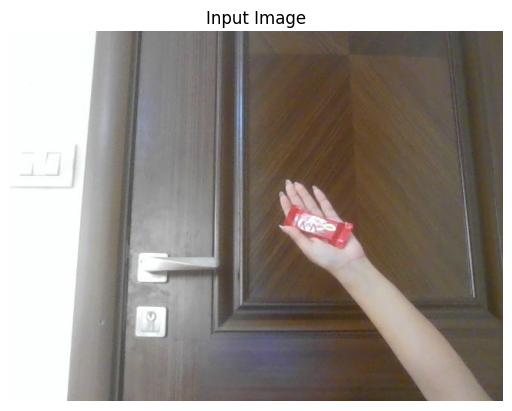

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Raw prediction: [[  0.0022997]]

🔹 Model 1 Prediction: Recyclable (0.0023)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
🔹 Model 2 Prediction: paper waste (0.9632)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 1 Plastic bag - wrapper, 13.0ms
Speed: 1.9ms preprocess, 13.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Plastic bag - wrapper']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 0.0022996508050709963, 'category': 'paper waste', 'confidence_model2': 0.9631951451301575, 'detections': ['Plastic bag - wrapper']}


In [ ]:
img_path = take_photo()

result11 = run_pipeline(img_path)
print(result11)

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


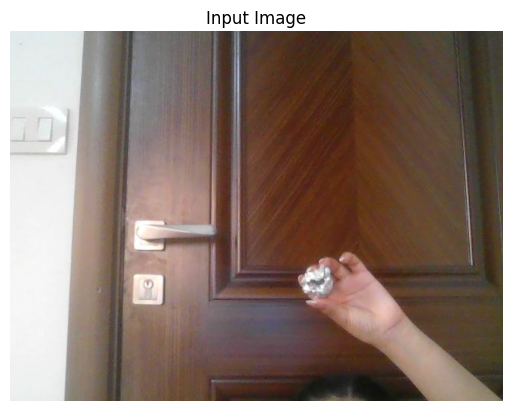

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Raw prediction: [[    0.34968]]

🔹 Model 1 Prediction: Recyclable (0.3497)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
🔹 Model 2 Prediction: paper waste (0.5898)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 1 Aluminium foil, 13.5ms
Speed: 2.4ms preprocess, 13.5ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Aluminium foil']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 0.34967732429504395, 'category': 'paper waste', 'confidence_model2': 0.5898388624191284, 'detections': ['Aluminium foil']}


In [ ]:
img_path = take_photo()

result15 = run_pipeline(img_path)
print(result15)

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


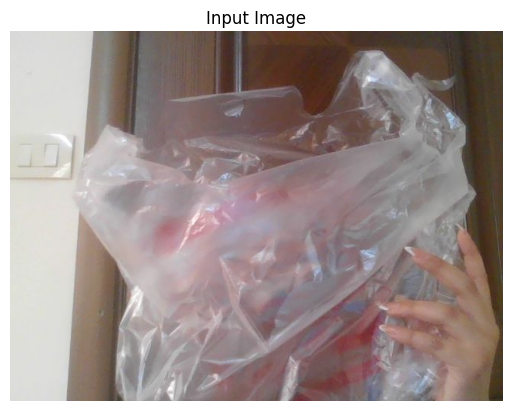

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raw prediction: [[ 0.00020486]]

🔹 Model 1 Prediction: Recyclable (0.0002)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
🔹 Model 2 Prediction: plastic waste (0.9772)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 1 Plastic bag - wrapper, 14.0ms
Speed: 2.3ms preprocess, 14.0ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Plastic bag - wrapper']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 0.00020485918503254652, 'category': 'plastic waste', 'confidence_model2': 0.9771996140480042, 'detections': ['Plastic bag - wrapper']}


In [ ]:
img_path = take_photo()

result20 = run_pipeline(img_path)
print(result20)

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


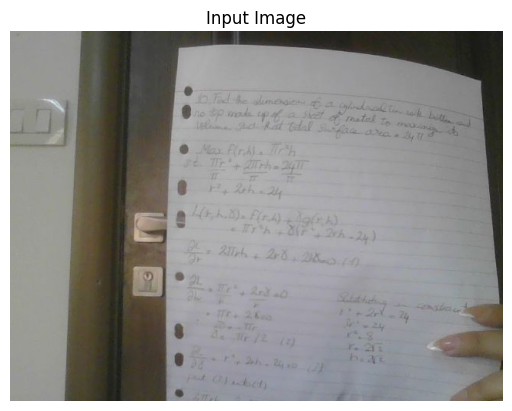

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Raw prediction: [[ 9.4781e-05]]

🔹 Model 1 Prediction: Recyclable (0.0001)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
🔹 Model 2 Prediction: paper waste (0.8406)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 1 Paper, 13.0ms
Speed: 2.2ms preprocess, 13.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Paper']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 9.478085121372715e-05, 'category': 'paper waste', 'confidence_model2': 0.8406082391738892, 'detections': ['Paper']}


In [ ]:
img_path = take_photo()

result21 = run_pipeline(img_path)
print(result21)

<IPython.core.display.Javascript object>

📸 Input Image: photo.jpg


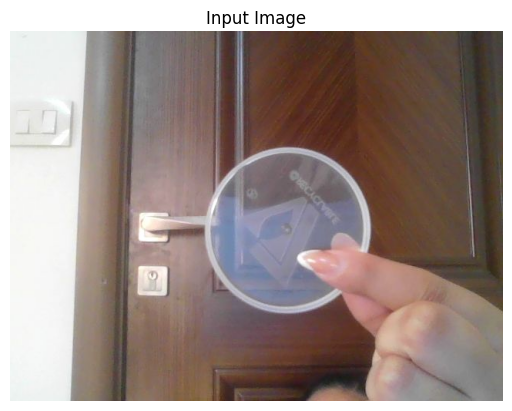

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raw prediction: [[   0.020355]]

🔹 Model 1 Prediction: Recyclable (0.0204)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
🔹 Model 2 Prediction: plastic waste (0.4515)

🔹 Running YOLO Detection...

image 1/1 /content/photo.jpg: 480x640 1 Cup, 1 Lid, 13.2ms
Speed: 2.1ms preprocess, 13.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
🔹 Detected Objects: ['Cup', 'Lid']
✅ Detection complete (check output images)
{'recyclable': 'Recyclable', 'confidence_model1': 0.020354995504021645, 'category': 'plastic waste', 'confidence_model2': 0.4515284299850464, 'detections': ['Cup', 'Lid']}


In [ ]:
img_path = take_photo()

result22 = run_pipeline(img_path)
print(result22)